# 02. Preprocessing & Data Pipeline - PneumoVision_AI

## 1. Pendahuluan

Selamat datang di tahap kedua pengembangan **PneumoVision_AI**! 🫁

Pada notebook sebelumnya (`01_EDA.ipynb`), kita telah berhasil mengidentifikasi karakteristik penting dari dataset *Chest X-Ray*:
1. **Ukuran Set Validasi Bawaan Terlalu Kecil**: Folder `val` bawaan hanya memiliki **16 citra** (8 Normal dan 8 Pneumonia). Jumlah ini tidak memadai untuk mengevaluasi performa model secara andal.
2. **Class Imbalance Nyata**: Data `train` didominasi oleh kelas PNEUMONIA (**3.875 citra** atau ~74,3%) dibandingkan NORMAL (**1.341 citra** atau ~25,7%).
3. **Variasi Dimensi Citra**: Resolusi asli berkisar dari ~384 px hingga lebih dari 2.700 px.
4. **Campuran Kanal Warna**: Terdapat citra dengan mode Grayscale (`'L'`) dan citra dengan 3 kanal (`'RGB'`).
5. **Kebersihan Data**: Tidak ditemukan file yang rusak (*zero corrupt files*) dan tidak ada kebocoran data antar split (*zero data leakage*).

> ⚠️ **Disclaimer Medis**:  
> *Notebook dan proyek ini dibuat murni untuk tujuan edukasi dan riset portofolio, serta **BUKAN** merupakan alat diagnosis medis resmi. Sistem ini tidak boleh digunakan untuk menggantikan keputusan klinis tenaga medis profesional.*

---

### Tujuan Notebook Ini
- Membentuk **Validation Split Baru** yang representatif dan *stratified* (20% dari data train) tanpa mengganggu data test.
- **Mengunci Test Set (624 citra)** murni untuk evaluasi akhir agar bebas dari kontaminasi (*data leakage*).
- Menghitung dan mendokumentasikan nilai **Class Weights** untuk menangani ketidakseimbangan kelas pada tahap training nanti.
- Merancang pipeline transformasi citra PyTorch: penyeragaman ukuran (*resize* ke 224x224), standardisasi 3 kanal (RGB), konversi tensor, dan normalisasi ImageNet.
- Menerapkan teknik **Data Augmentation** yang aman secara medis pada data train (rotasi ringan, flip horizontal, sedikit penyesuaian kontras tanpa flip vertikal).
- Membangun kelas PyTorch `Dataset` dan `DataLoader` yang modular dan siap digunakan untuk pelatihan model di `03_Baseline_Model.ipynb`.

## 2. Import Library & Reproducibility Setup

Kita mengimpor pustaka yang dibutuhkan untuk manipulasi data dan pembuatan pipeline PyTorch, serta menetapkan *random seed* agar seluruh pemisahan data dan transformasi bersifat konsisten dan *reproducible*.

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# Menetapkan random seed untuk memastikan reproduksibilitas eksperimen
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Path dataset menggunakan path relatif yang aman
data_dir = Path('../XRayData/chest_xray') if Path('../XRayData/chest_xray').exists() else Path('XRayData/chest_xray')

print(f"Direktori dataset aktif : {data_dir.resolve().name}")
print(f"Random Seed ditetapkan  : {RANDOM_SEED}")

Direktori dataset aktif : chest_xray
Random Seed ditetapkan  : 42


## 3. Pembagian Dataset (Stratified Train-Validation Split)

### Mengapa Perlu Split Validasi Baru?
Folder validasi bawaan (`val/`) hanya memiliki 16 citra. Jika kita menggunakan 16 citra tersebut sebagai patokan validasi saat melatih model, satu prediksi yang salah saja akan mengubah nilai akurasi sebesar $1/16 = 6.25\%$. Metrik akan berfluktuasi liar dan memicu pemilihan checkpoint yang tidak optimal.

### Aturan Pemisahan:
1. Kita mengambil seluruh data dari folder `train/` (**5.216 citra**).
2. Kita pisahkan menjadi **Train Baru (80%)** dan **Validation Baru (20%)** menggunakan metode **Stratified Split** agar rasio kelas NORMAL dan PNEUMONIA tetap sama persis di kedua kelompok.
3. **Data Test (624 citra) TIDAK disentuh sama sekali**. Test set tetap terkunci rapat untuk evaluasi final di masa mendatang.

In [2]:
# Mapping label numerik yang jelas dan terdokumentasi
LABEL_MAP = {'NORMAL': 0, 'PNEUMONIA': 1}
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

# 1. Kumpulkan seluruh file dari folder train asli
train_orig_normal = sorted([p for p in (data_dir / 'train' / 'NORMAL').iterdir() if p.is_file() and not p.name.startswith('.')])
train_orig_pneu = sorted([p for p in (data_dir / 'train' / 'PNEUMONIA').iterdir() if p.is_file() and not p.name.startswith('.')])

raw_train_paths = train_orig_normal + train_orig_pneu
raw_train_labels = [LABEL_MAP['NORMAL']] * len(train_orig_normal) + [LABEL_MAP['PNEUMONIA']] * len(train_orig_pneu)

# 2. Kumpulkan seluruh file dari folder test asli (TETAP DIKUNCI)
test_orig_normal = sorted([p for p in (data_dir / 'test' / 'NORMAL').iterdir() if p.is_file() and not p.name.startswith('.')])
test_orig_pneu = sorted([p for p in (data_dir / 'test' / 'PNEUMONIA').iterdir() if p.is_file() and not p.name.startswith('.')])

test_paths = test_orig_normal + test_orig_pneu
test_labels = [LABEL_MAP['NORMAL']] * len(test_orig_normal) + [LABEL_MAP['PNEUMONIA']] * len(test_orig_pneu)

# 3. Lakukan Stratified Split 80:20 pada data train
train_paths, val_paths, train_labels, val_labels = train_test_split(
    raw_train_paths,
    raw_train_labels,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=raw_train_labels
)

# Buat tabel ringkasan perbandingan split
split_overview = pd.DataFrame([
    {
        'Split': 'Train (Baru - 80%)',
        'NORMAL': train_labels.count(0),
        'PNEUMONIA': train_labels.count(1),
        'Total': len(train_labels),
        '% PNEUMONIA': f"{(train_labels.count(1)/len(train_labels)*100):.1f}%"
    },
    {
        'Split': 'Validation (Baru - 20%)',
        'NORMAL': val_labels.count(0),
        'PNEUMONIA': val_labels.count(1),
        'Total': len(val_labels),
        '% PNEUMONIA': f"{(val_labels.count(1)/len(val_labels)*100):.1f}%"
    },
    {
        'Split': 'Test (Terkunci)',
        'NORMAL': test_labels.count(0),
        'PNEUMONIA': test_labels.count(1),
        'Total': len(test_labels),
        '% PNEUMONIA': f"{(test_labels.count(1)/len(test_labels)*100):.1f}%"
    }
])

split_overview

,Split,NORMAL,PNEUMONIA,Total,% PNEUMONIA
0,Train (Baru - 80%),1073,3099,4172,74.3%
1,Validation (Baru - 20%),268,776,1044,74.3%
2,Test (Terkunci),234,390,624,62.5%


### 🔍 Insight Hasil Split Dataset Baru:
- **Train Baru**: Berisi **4.172 citra** (1.073 Normal dan 3.099 Pneumonia).
- **Validation Baru**: Berisi **1.044 citra** (268 Normal dan 776 Pneumonia). Ini adalah ukuran sampel validasi yang sangat representatif dan memadai untuk memonitor metrik evaluasi secara stabil.
- **Proporsi Stratified Terjaga**: Persentase Pneumonia pada Train baru dan Validation baru bernilai identik (**74,3%** vs **74,3%**).
- **Test Set Utuh**: Tetap berjumlah **624 citra** asli tanpa ada kebocoran informasi dari data latih maupun validasi.

## 4. Analisis Class Imbalance & Perhitungan Class Weights

Kita tahu bahwa data training memiliki ketidakseimbangan kelas (Pneumonia ~2,89 kali lebih banyak daripada Normal).

Untuk mengatasi hal ini saat proses pelatihan model di notebook berikutnya, kita tidak perlu membuang data (*undersampling*) atau menggandakan data mentah secara artifisial (*oversampling*). Pendekatan yang lebih elegan dan umum digunakan dalam deep learning adalah menggunakan **Class Weighting** pada fungsi *loss*.

Mari kita hitung nilai bobot kelas tersebut sekarang agar siap digunakan saat pelatihan model.

In [3]:
n_train_total = len(train_labels)
n_train_normal = train_labels.count(0)
n_train_pneu = train_labels.count(1)

# 1. Bobot seimbang untuk Cross-Entropy Loss (2 kelas)
# Formula: w_j = N / (2 * N_j)
weight_normal = n_train_total / (2.0 * n_train_normal)
weight_pneu = n_train_total / (2.0 * n_train_pneu)
class_weights_ce = torch.tensor([weight_normal, weight_pneu], dtype=torch.float32)

# 2. Bobot untuk BCEWithLogitsLoss (pos_weight)
# Formula: pos_weight = N_neg / N_pos
pos_weight_bce = torch.tensor([n_train_normal / n_train_pneu], dtype=torch.float32)

print("=== Ringkasan Penanganan Class Imbalance (Data Train) ===")
print(f"Jumlah NORMAL (Kelas 0)    : {n_train_normal} citra")
print(f"Jumlah PNEUMONIA (Kelas 1)  : {n_train_pneu} citra")
print(f"Rasio PNEUMONIA : NORMAL    : {n_train_pneu / n_train_normal:.2f} : 1")
print("-" * 55)
print(f"Class Weights (CrossEntropy): [NORMAL: {weight_normal:.4f}, PNEUMONIA: {weight_pneu:.4f}]")
print(f"Pos Weight (BCEWithLogits)  : {pos_weight_bce.item():.4f}")
print("\nCatatan: Bobot ini siap disuplai ke fungsi Loss saat eksperimen model dimulai.")

=== Ringkasan Penanganan Class Imbalance (Data Train) ===
Jumlah NORMAL (Kelas 0)    : 1073 citra
Jumlah PNEUMONIA (Kelas 1)  : 3099 citra
Rasio PNEUMONIA : NORMAL    : 2.89 : 1
-------------------------------------------------------
Class Weights (CrossEntropy): [NORMAL: 1.9441, PNEUMONIA: 0.6731]
Pos Weight (BCEWithLogits)  : 0.3462

Catatan: Bobot ini siap disuplai ke fungsi Loss saat eksperimen model dimulai.


### 🔍 Insight Class Weights:
- Kelas NORMAL diberikan bobot penalti yang lebih tinggi (**~1,94**) dibanding kelas PNEUMONIA (**~0,67**) pada fungsi loss.
- Hal ini memastikan model dihukum lebih berat jika salah memprediksi citra Normal, sehingga model terdorong untuk mempelajari kedua kelas secara adil tanpa bias mayoritas.

## 5. Perancangan Transformasi & Data Augmentation

Mari kita tentukan pipeline transformasi citra dengan tahapan:
1. **Resize (224x224)**: Dimensi input standar yang umum digunakan pada arsitektur CNN populer (seperti ResNet, DenseNet, dan EfficientNet). Ukuran ini menyeimbangkan ketajaman visual dan efisiensi memori GPU.
2. **Konversi 3 Kanal (RGB)**: Menyeragamkan citra grayscale (1 kanal) menjadi 3 kanal agar kompatibel dengan bobot model pretrained ImageNet.
3. **Normalisasi ImageNet**:
   - Mean: `[0.485, 0.456, 0.406]`
   - Std: `[0.229, 0.224, 0.225]`  
   *Alasan*: Normalisasi membawa nilai piksel ke distribusi standar berpusat di nol (*zero-centered*). Ini mempercepat konvergensi *gradient descent* dan menjaga stabilitas aktivasi.
4. **Augmentasi Khusus Train**:
   - `RandomRotation(degrees=10)`: Meniru sedikit kemiringan posisi tubuh pasien di depan kaset rontgen.
   - `RandomHorizontalFlip(p=0.5)`: Memberikan variasi orientasi lateral simetris tanpa merusak pola infeksi paru.
   - `ColorJitter(brightness=0.1, contrast=0.1)`: Meniru variasi dosis eksposur dan kontras antar mesin rontgen.
   - **DILARANG memakai Vertical Flip**: Karena posisi anatomi organ dada manusia (jantung, diafragma, trakea) tidak pernah terbalik ke bawah.
5. **Validation & Test**: **Tanpa augmentasi acak**. Murni hanya Resize, ToTensor, dan Normalisasi agar evaluasi bersifat deterministik dan objektif.

In [4]:
# Parameter standar transformasi
IMAGE_SIZE = (224, 224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# 1. Pipeline Transformasi untuk Data TRAINING (dengan augmentasi ringan)
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# 2. Pipeline Transformasi untuk Data VALIDATION (deterministik)
val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# 3. Pipeline Transformasi untuk Data TEST (deterministik & terkunci)
test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Pipeline transformasi berhasil didefinisikan untuk Train, Validation, dan Test.")

Pipeline transformasi berhasil didefinisikan untuk Train, Validation, dan Test.


## 6. Implementasi PyTorch Dataset & DataLoader

Kita membuat kelas kustom `ChestXRayDataset` yang mewarisi `torch.utils.data.Dataset`. Kelas ini bertanggung jawab membuka citra dengan PIL, mengonversinya ke format RGB 3 kanal secara otomatis, dan menerapkan objek transformasi PyTorch.

In [5]:
class ChestXRayDataset(Dataset):
    """
    PyTorch Dataset kustom untuk citra Chest X-Ray.
    Memastikan seluruh citra otomatis dikonversi ke format RGB (3 kanal).
    """
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]

        # Buka gambar dan pastikan format 3 kanal RGB selalu konsisten
        with Image.open(path) as img:
            img_rgb = img.convert('RGB')

        if self.transform is not None:
            image_tensor = self.transform(img_rgb)
        else:
            image_tensor = transforms.ToTensor()(img_rgb)

        target = torch.tensor(label, dtype=torch.long)
        return image_tensor, target

# Inisialisasi Dataset instances
train_dataset = ChestXRayDataset(train_paths, train_labels, transform=train_transform)
val_dataset = ChestXRayDataset(val_paths, val_labels, transform=val_transform)
test_dataset = ChestXRayDataset(test_paths, test_labels, transform=test_transform)

# Inisialisasi DataLoader instances
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # Nilai 0 paling stabil dan aman di berbagai sistem operasi (termasuk Windows)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"DataLoader berhasil dibuat (Batch Size = {BATCH_SIZE}):")
print(f"- Train Batches      : {len(train_loader)} batch ({len(train_dataset)} sampel)")
print(f"- Validation Batches : {len(val_loader)} batch ({len(val_dataset)} sampel)")
print(f"- Test Batches       : {len(test_loader)} batch ({len(test_dataset)} sampel)")

DataLoader berhasil dibuat (Batch Size = 32):
- Train Batches      : 131 batch (4172 sampel)
- Validation Batches : 33 batch (1044 sampel)
- Test Batches       : 20 batch (624 sampel)


## 7. Visualisasi Hasil Preprocessing & Augmentasi

Sebelum melangkah ke tahap pemodelan, kita perlu menginspeksi secara visual citra yang keluar dari pipeline untuk memastikan:
1. Augmentasi tidak merusak struktur anatomi paru.
2. Citra tensor yang sudah dinormalisasi dapat dikembalikan (*un-normalize*) dengan benar ke rentang visual [0, 1].

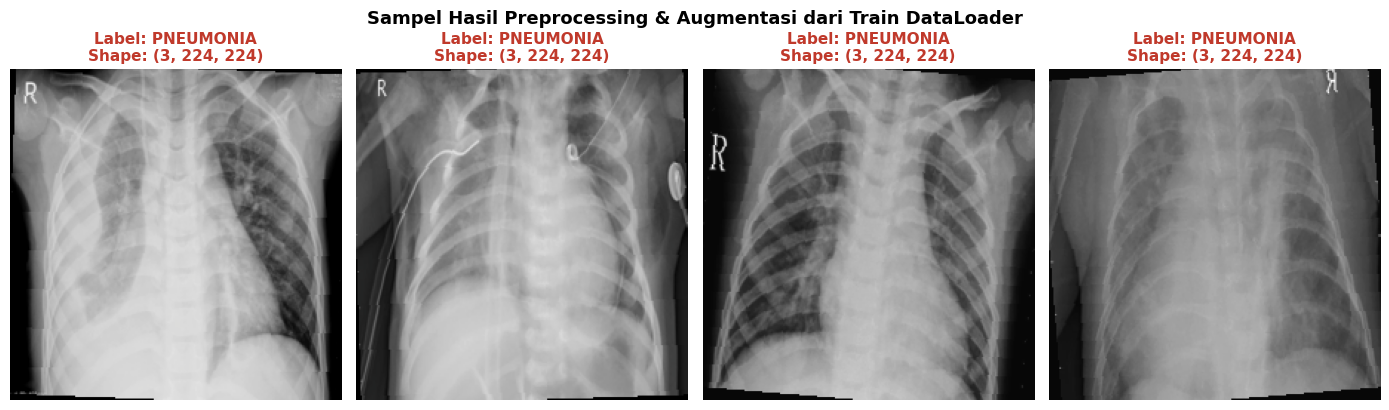

In [6]:
def unnormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """
    Mengembalikan tensor ternormalisasi ImageNet ke rentang [0, 1] agar dapat divisualisasikan.
    """
    t = tensor.clone().detach().cpu()
    for c in range(3):
        t[c] = t[c] * std[c] + mean[c]
    t = torch.clamp(t, 0.0, 1.0)
    # Ubah format dari (Channel, Height, Width) ke (Height, Width, Channel) untuk matplotlib
    return t.permute(1, 2, 0).numpy()

# Ambil 1 batch dari train_loader
sample_images, sample_targets = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i in range(4):
    img_display = unnormalize(sample_images[i])
    label_idx = sample_targets[i].item()
    class_name = CLASS_NAMES[label_idx]
    color = '#1E8449' if class_name == 'NORMAL' else '#C0392B'

    axes[i].imshow(img_display)
    axes[i].set_title(f"Label: {class_name}\nShape: {tuple(sample_images[i].shape)}", fontsize=11, fontweight='bold', color=color)
    axes[i].axis('off')

plt.suptitle('Sampel Hasil Preprocessing & Augmentasi dari Train DataLoader', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 🔍 Insight Visualisasi:
- Citra berhasil diubah ukurannya ke dimensi seragam `(3, 224, 224)`.
- Detail tulang rusuk, bayangan jantung, dan parenkim paru tetap tampak jelas dan tajam.
- Rotasi ringan (±10°) dan sedikit variasi kontras memberikan keragaman visual yang wajar tanpa mendistorsi integritas citra radiograf.

## 8. Validasi Menyeluruh Pipeline

Kita lakukan serangkaian pemeriksaan otomatis (*sanity checks*) untuk memverifikasi bahwa pipeline berjalan sempurna dan siap pakai.

In [7]:
# 1. Validasi jumlah data total
assert len(train_dataset) == 4172, f"Jumlah train salah: {len(train_dataset)}"
assert len(val_dataset) == 1044, f"Jumlah validation salah: {len(val_dataset)}"
assert len(test_dataset) == 624, f"Jumlah test salah: {len(test_dataset)}"
assert len(train_dataset) + len(val_dataset) == 5216, "Total train+val tidak cocok dengan data train asli"

# 2. Validasi mapping label
assert set(train_labels) == {0, 1}, "Label train mengandung nilai tak terduga"
assert set(val_labels) == {0, 1}, "Label validation mengandung nilai tak terduga"
assert set(test_labels) == {0, 1}, "Label test mengandung nilai tak terduga"

# 3. Validasi pengambilan batch dari seluruh DataLoader
train_b_imgs, train_b_lbls = next(iter(train_loader))
val_b_imgs, val_b_lbls = next(iter(val_loader))
test_b_imgs, test_b_lbls = next(iter(test_loader))

assert train_b_imgs.shape == torch.Size([32, 3, 224, 224]), f"Shape batch train salah: {train_b_imgs.shape}"
assert val_b_imgs.shape == torch.Size([32, 3, 224, 224]), f"Shape batch val salah: {val_b_imgs.shape}"
assert test_b_imgs.shape == torch.Size([32, 3, 224, 224]), f"Shape batch test salah: {test_b_imgs.shape}"

assert train_b_imgs.dtype == torch.float32, "Tipe data tensor bukan float32"
assert train_b_lbls.dtype == torch.int64, "Tipe data target bukan int64 (long)"

print("=== Hasil Pemeriksaan Validasi Pipeline ===")
print("[OK] Jumlah data per split sesuai target (Train: 4.172, Val: 1.044, Test: 624)")
print("[OK] Mapping label valid: NORMAL = 0, PNEUMONIA = 1")
print(f"[OK] Shape batch train      : {tuple(train_b_imgs.shape)}")
print(f"[OK] Shape batch validation : {tuple(val_b_imgs.shape)}")
print(f"[OK] Shape batch test       : {tuple(test_b_imgs.shape)}")
print(f"[OK] Rentang nilai tensor   : min = {train_b_imgs.min():.2f}, max = {train_b_imgs.max():.2f}")
print("\n[SUKSES] Seluruh pemeriksaan pipeline lolos tanpa error! Pipeline siap digunakan untuk pemodelan.")

=== Hasil Pemeriksaan Validasi Pipeline ===
[OK] Jumlah data per split sesuai target (Train: 4.172, Val: 1.044, Test: 624)
[OK] Mapping label valid: NORMAL = 0, PNEUMONIA = 1
[OK] Shape batch train      : (32, 3, 224, 224)
[OK] Shape batch validation : (32, 3, 224, 224)
[OK] Shape batch test       : (32, 3, 224, 224)
[OK] Rentang nilai tensor   : min = -2.12, max = 2.64

[SUKSES] Seluruh pemeriksaan pipeline lolos tanpa error! Pipeline siap digunakan untuk pemodelan.


## 9. Kesimpulan & Rekomendasi

Berikut adalah ringkasan keputusan teknis yang telah diimplementasikan dalam notebook ini:

1. **Validation Split Representatif**:
   - Set validasi bawaan yang hanya berjumlah 16 citra telah digantikan dengan **Stratified 80:20 Split dari data Train**.
   - Menghasilkan **4.172 citra Train** dan **1.044 citra Validation** dengan rasio kelas yang seimbang dan konsisten.
   - Set **Test (624 citra) tetap dikunci** dan tidak tersentuh.

2. **Strategi Preprocessing**:
   - Setiap citra dikonversi ke format 3 kanal (RGB) dan diubah ukurannya ke dimensi `(224, 224)`.
   - Diterapkan normalisasi standar ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`).

3. **Data Augmentation Aman**:
   - Augmentasi ringan (rotasi ±10°, flip horizontal, penyesuaian kecerahan/kontras) hanya diterapkan pada data latih.
   - Augmentasi acak tidak diterapkan pada data validasi maupun data uji agar hasil evaluasi bersifat adil dan deterministik.

4. **Kesiapan Class Imbalance**:
   - Nilai *Class Weights* (`weight_normal = 1.944`, `weight_pneu = 0.673`) telah dihitung dan siap digunakan pada fungsi loss saat pelatihan model.

---

### 📌 Hal yang Akan Diputuskan pada Tahap Baseline Model (`03_Baseline_Model.ipynb`):
- Merancang arsitektur model Convolutional Neural Network (CNN) sederhana dari awal.
- Menentukan fungsi loss (misal: `CrossEntropyLoss` dengan `weight` vs `BCEWithLogitsLoss` dengan `pos_weight`).
- Memilih optimizer awal (misal: Adam) dan learning rate dasar.
- Melatih model baseline pertama untuk menetapkan batas bawah (*baseline benchmark*) performa.

---

## 📖 Ringkasan Notebook

> **Ringkasan 02_Preprocessing.ipynb**:  
> Notebook ini berhasil menyelesaikan persiapan pipeline data PyTorch untuk proyek PneumoVision_AI. Dengan membuat validation split baru (1.044 sampel) secara stratified dari data train, mengunci test set (624 sampel), merancang augmentasi domain-safe, mengonversi citra ke RGB (224x224), serta menghitung class weights, data kini berada dalam kondisi optimal untuk pelatihan model di `03_Baseline_Model.ipynb` tanpa modifikasi file fisik pada dataset asli.